In [1]:
!pip install opencv-python matplotlib imageio gdown tensorflow


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import cv2
import tensorflow as tf
import numpy as np
from typing import List
from matplotlib import pyplot as plt
import imageio
import gdown

In [3]:
physical_devices = tf.config.list_physical_devices('GPU')

if physical_devices:
    for device in physical_devices:
        tf.config.experimental.set_memory_growth(device, True)
    print("GPU available:", physical_devices)
else:
    print("Running on CPU")

Running on CPU


In [4]:
PROJECT_DIR = r"D:\Eyad2\Downloads\LipNet-Speech-Recognition"

DATA_DIR = os.path.join(PROJECT_DIR, "data")
VIDEO_DIR = os.path.join(DATA_DIR, "s1")
ALIGNMENT_DIR = os.path.join(DATA_DIR, "alignments", "s1")
MODEL_DIR = os.path.join(PROJECT_DIR, "models")

os.makedirs(MODEL_DIR, exist_ok=True)

print("Project:", PROJECT_DIR)
print("Data:", DATA_DIR)
print("Videos:", VIDEO_DIR)
print("Alignments:", ALIGNMENT_DIR)

Project: D:\Eyad2\Downloads\LipNet-Speech-Recognition
Data: D:\Eyad2\Downloads\LipNet-Speech-Recognition\data
Videos: D:\Eyad2\Downloads\LipNet-Speech-Recognition\data\s1
Alignments: D:\Eyad2\Downloads\LipNet-Speech-Recognition\data\alignments\s1


In [5]:
url = 'https://drive.google.com/uc?id=1YlvpDLix3S-U8fd-gqRwPcWXAXm8JwjL'

data_zip = os.path.join(PROJECT_DIR, 'data.zip')

if not os.path.exists(DATA_DIR):
    gdown.download(url, data_zip, quiet=False)
    gdown.extractall(data_zip, PROJECT_DIR)
    print("Dataset extracted.")
else:
    print("Dataset already exists.")

Dataset already exists.


In [6]:
print("Data directory exists:", os.path.exists(DATA_DIR))
print("Video directory exists:", os.path.exists(VIDEO_DIR))
print("Alignment directory exists:", os.path.exists(ALIGNMENT_DIR))

video_test = os.path.join(VIDEO_DIR, "bbal6n.mpg")
alignment_test = os.path.join(ALIGNMENT_DIR, "bbal6n.align")

print("\nTest video:", video_test, "Exists:", os.path.exists(video_test))
print("Test alignment:", alignment_test, "Exists:", os.path.exists(alignment_test))

Data directory exists: True
Video directory exists: True
Alignment directory exists: True

Test video: D:\Eyad2\Downloads\LipNet-Speech-Recognition\data\s1\bbal6n.mpg Exists: True
Test alignment: D:\Eyad2\Downloads\LipNet-Speech-Recognition\data\alignments\s1\bbal6n.align Exists: True


In [7]:
def load_video(path: str) -> tf.Tensor:
    cap = cv2.VideoCapture(path)

    if not cap.isOpened():
        raise FileNotFoundError(f"Could not open video:\n{path}")

    frames = []
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    for _ in range(frame_count):
        ret, frame = cap.read()
        if not ret:
            break

        frame = tf.image.rgb_to_grayscale(frame)
        frames.append(frame[190:236, 80:220, :])

    cap.release()

    mean = tf.math.reduce_mean(frames)
    std = tf.math.reduce_std(tf.cast(frames, tf.float32))

    return tf.cast((frames - mean), tf.float32) / std

In [8]:
vocab = [x for x in "abcdefghijklmnopqrstuvwxyz'?!123456789 "]
print("Vocabulary size:", len(vocab))

Vocabulary size: 39


In [9]:
char_to_num = tf.keras.layers.StringLookup(vocabulary=vocab, oov_token="")
num_to_char = tf.keras.layers.StringLookup(
    vocabulary=char_to_num.get_vocabulary(),
    oov_token="",
    invert=True
)

print(f"The vocabulary is: {char_to_num.get_vocabulary()} (size = {char_to_num.vocabulary_size()})")

The vocabulary is: ['', np.str_('a'), np.str_('b'), np.str_('c'), np.str_('d'), np.str_('e'), np.str_('f'), np.str_('g'), np.str_('h'), np.str_('i'), np.str_('j'), np.str_('k'), np.str_('l'), np.str_('m'), np.str_('n'), np.str_('o'), np.str_('p'), np.str_('q'), np.str_('r'), np.str_('s'), np.str_('t'), np.str_('u'), np.str_('v'), np.str_('w'), np.str_('x'), np.str_('y'), np.str_('z'), np.str_("'"), np.str_('?'), np.str_('!'), np.str_('1'), np.str_('2'), np.str_('3'), np.str_('4'), np.str_('5'), np.str_('6'), np.str_('7'), np.str_('8'), np.str_('9'), np.str_(' ')] (size = 40)


In [10]:
def load_alignments(path: str) -> tf.Tensor:
    with open(path, 'r') as f:
        lines = f.readlines()

    tokens = []
    for line in lines:
        line = line.split()
        if len(line) >= 3 and line[2] != 'sil':
            tokens = [*tokens, ' ', line[2]]

    if not tokens:
        raise ValueError(f"No alignment tokens found:\n{path}")

    text = tf.strings.unicode_split(tokens, input_encoding='UTF-8')
    return char_to_num(tf.reshape(text, (-1)))[1:]

In [11]:
def load_data(path):
    if isinstance(path, tf.Tensor):
        path = path.numpy()
    if isinstance(path, bytes):
        path = path.decode('utf-8')

    file_name = os.path.splitext(os.path.basename(path))[0]

    video_path = os.path.join(VIDEO_DIR, f"{file_name}.mpg")
    alignment_path = os.path.join(ALIGNMENT_DIR, f"{file_name}.align")

    frames = load_video(video_path)
    alignments = load_alignments(alignment_path)

    return frames, alignments

In [12]:
test_path = os.path.join(VIDEO_DIR, "bbal6n.mpg")
frames, alignments = load_data(test_path)

print("Frames shape:", frames.shape)
print("Alignments shape:", alignments.shape)

Frames shape: (75, 46, 140, 1)
Alignments shape: (21,)


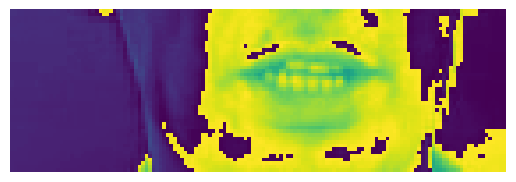

In [13]:
plt.imshow(frames[40])
plt.axis('off')
plt.show()

In [14]:
text = tf.strings.reduce_join([bytes.decode(x) for x in num_to_char(alignments.numpy()).numpy()])
print(text.numpy().decode('utf-8'))

bin blue at l six now


In [15]:
def mappable_function(path):
    frames, alignments = tf.py_function(load_data, [path], (tf.float32, tf.int64))
    frames.set_shape([75, 46, 140, 1])
    alignments.set_shape([None])
    return frames, alignments

In [16]:
video_pattern = os.path.join(VIDEO_DIR, "*.mpg")

data = tf.data.Dataset.list_files(video_pattern, shuffle=True)
data = data.shuffle(500, reshuffle_each_iteration=False)
data = data.map(mappable_function, num_parallel_calls=tf.data.AUTOTUNE)
data = data.padded_batch(2, padded_shapes=([75, 46, 140, 1], [40]))
data = data.prefetch(tf.data.AUTOTUNE)

train = data.take(450)
test = data.skip(450)

print("Dataset created.")
print("Train batches:", len(train))
print("Test batches:", len(test))

Dataset created.
Train batches: 450
Test batches: 50


In [17]:
sample_data = data.as_numpy_iterator()
val = next(sample_data)

print("Video batch shape:", val[0].shape)
print("Alignment batch shape:", val[1].shape)

Video batch shape: (2, 75, 46, 140, 1)
Alignment batch shape: (2, 40)


In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv3D, LSTM, Dense, Dropout, Bidirectional,
    MaxPool3D, Activation, TimeDistributed, Flatten
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler

In [ ]:
model = Sequential()

model.add(Conv3D(128, 3, input_shape=(75, 46, 140, 1), padding='same'))
model.add(Activation('relu'))
model.add(MaxPool3D((1, 2, 2)))

model.add(Conv3D(256, 3, padding='same'))
model.add(Activation('relu'))
model.add(MaxPool3D((1, 2, 2)))

model.add(Conv3D(75, 3, padding='same'))
model.add(Activation('relu'))
model.add(MaxPool3D((1, 2, 2)))

model.add(TimeDistributed(Flatten()))

model.add(Bidirectional(LSTM(128, kernel_initializer='Orthogonal', return_sequences=True)))
model.add(Dropout(0.5))

model.add(Bidirectional(LSTM(128, kernel_initializer='Orthogonal', return_sequences=True)))
model.add(Dropout(0.5))

model.add(Dense(char_to_num.vocabulary_size() + 1, kernel_initializer='he_normal', activation='softmax'))

model.summary()

d:\Eyad2\Downloads\LipNet-Speech-Recognition\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d (Conv3D)                 │ (None, 75, 46, 140,    │         3,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 75, 46, 140,    │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 75, 23, 70,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 75, 23, 70,     │       884,992 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 75, 23, 70,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (None, 75, 11, 35,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 75, 11, 35, 75) │       518,475 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 75, 11, 35, 75) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_2 (MaxPooling3D)  │ (None, 75, 5, 17, 75)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 75, 6375)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 75, 256)        │     6,660,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 75, 256)        │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 75, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 75, 41)         │        10,537 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,471,924 (32.32 MB)

 Trainable params: 8,471,924 (32.32 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
import math

def scheduler(epoch, lr):
    if epoch < 75:
        return float(lr)
    else:
        return float(lr * math.exp(-0.03))

In [21]:
def CTCLoss(y_true, y_pred):
    batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")
    input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")
    label_length = tf.cast(tf.shape(y_true)[1], dtype="int64")

    input_length = input_length * tf.ones(shape=(batch_len, 1), dtype="int64")
    label_length = label_length * tf.ones(shape=(batch_len, 1), dtype="int64")

    loss = tf.keras.backend.ctc_batch_cost(y_true, y_pred, input_length, label_length)
    return loss

In [30]:
class ProduceExample(tf.keras.callbacks.Callback):
    def __init__(self, dataset):
        super().__init__()
        self.dataset = dataset.as_numpy_iterator()

    def on_epoch_end(self, epoch, logs=None):
        try:
            data = next(self.dataset)
        except StopIteration:
            self.dataset = test.as_numpy_iterator()
            data = next(self.dataset)

        yhat = self.model.predict(data[0])
        decoded = tf.keras.backend.ctc_decode(
            yhat, input_length=[75, 75], greedy=False
        )[0][0].numpy()

        print(f"\nEpoch {epoch + 1}")
        for i in range(len(yhat)):
            original = tf.strings.reduce_join(
                num_to_char(data[1][i])
            ).numpy().decode('utf-8')
            prediction = tf.strings.reduce_join(
                num_to_char(decoded[i])
            ).numpy().decode('utf-8')

            print("Original:", original)
            print("Prediction:", prediction)
            print("~" * 100)

In [31]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss=CTCLoss)
print("Model compiled.")

Model compiled.


In [32]:
checkpoint_path = os.path.join(MODEL_DIR, "checkpoint.weights.h5")

checkpoint_callback = ModelCheckpoint(
    checkpoint_path,
    monitor='loss',
    save_weights_only=True,
    save_best_only=True,
    verbose=1
)

schedule_callback = LearningRateScheduler(scheduler, verbose=1)
example_callback = ProduceExample(test)

print("Checkpoint path:", checkpoint_path)

Checkpoint path: D:\Eyad2\Downloads\LipNet-Speech-Recognition\models\checkpoint.weights.h5


In [33]:
checkpoint_path = os.path.join(MODEL_DIR, "checkpoint.weights.h5")

model.load_weights(checkpoint_path)
print("Resumed weights from epoch 71 checkpoint.")

model.optimizer.learning_rate.assign(2e-5)
print("Learning rate reset to:", model.optimizer.learning_rate.numpy())

initial_epoch = 75

history = model.fit(
    train,
    validation_data=test,
    epochs=150,
    initial_epoch=initial_epoch,
    callbacks=[checkpoint_callback, schedule_callback, example_callback]
)

Resumed weights from epoch 71 checkpoint.
Learning rate reset to: 2e-05

Epoch 76: LearningRateScheduler setting learning rate to 1.940891018065984e-05.
Epoch 76/150


d:\Eyad2\Downloads\LipNet-Speech-Recognition\venv\Lib\site-packages\keras\src\saving\saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam_1', because it has 2 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(store)
d:\Eyad2\Downloads\LipNet-Speech-Recognition\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - loss: 7.9100
Epoch 76: loss improved from None to 7.91002, saving model to D:\Eyad2\Downloads\LipNet-Speech-Recognition\models\checkpoint.weights.h5

Epoch 76: finished saving model to D:\Eyad2\Downloads\LipNet-Speech-Recognition\models\checkpoint.weights.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step

Epoch 76
Original: lay green by s seven soon
Prediction: lay gren by s seven son
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Original: lay green at l eight now
Prediction: lay gren at l eight now
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
450/450 ━━━━━━━━━━━━━━━━━━━━ 1887s 4s/step - loss: 7.9100 - val_loss: 5.1817 - learning_rate: 1.9409e-05

Epoch 77: LearningRateScheduler setting learning rate to 1.883528981978722e-05.
Epoch 77/150
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - loss: 7.7952
Epoch 77: loss improved from 7.91002 to 7.79515, savin

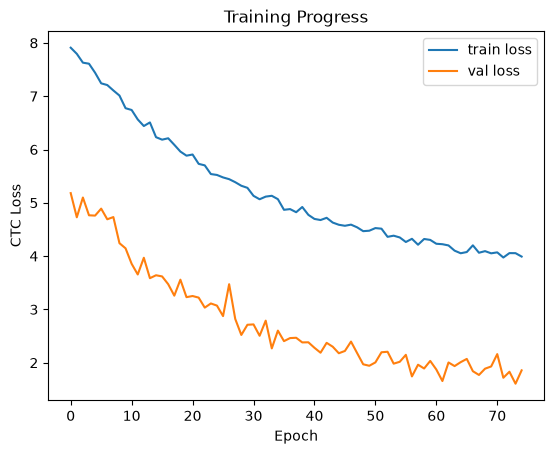

In [34]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('CTC Loss')
plt.legend()
plt.title('Training Progress')
plt.show()

In [35]:
test_data = test.as_numpy_iterator()
sample = next(test_data)

yhat = model.predict(sample[0])

decoded = tf.keras.backend.ctc_decode(
    yhat, input_length=[75] * len(sample[0]), greedy=False
)[0][0].numpy()

print("=" * 80)
for i in range(len(sample[0])):
    real_text = tf.strings.reduce_join(
        [num_to_char(word) for word in sample[1][i]]
    ).numpy().decode("utf-8")

    predicted_text = tf.strings.reduce_join(
        [num_to_char(word) for word in decoded[i]]
    ).numpy().decode("utf-8")

    print("REAL       :", real_text)
    print("PREDICTION :", predicted_text)
    print("-" * 80)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
REAL       : lay green with t three again
PREDICTION : lay gren with t thre again
--------------------------------------------------------------------------------
REAL       : lay blue by y three soon
PREDICTION : lay blue by y thre son
--------------------------------------------------------------------------------


In [36]:
import difflib

# GRID corpus fixed vocabulary (every sentence is built only from these words)
GRID_VOCAB = [
    "bin", "lay", "place", "set",                      # command
    "blue", "green", "red", "white",                   # color
    "at", "by", "in", "with",                           # preposition
    "a", "b", "c", "d", "e", "f", "g", "h", "i", "j",   # letter (GRID excludes 'w')
    "k", "l", "m", "n", "o", "p", "q", "r", "s", "t",
    "u", "v", "x", "y", "z",
    "zero", "one", "two", "three", "four",               # digit
    "five", "six", "seven", "eight", "nine",
    "again", "now", "please", "soon"                     # adverb
]

def correct_sentence(sentence: str) -> str:
    words = sentence.strip().split()
    corrected = []
    for w in words:
        if w in GRID_VOCAB:
            corrected.append(w)  # already valid, leave it
        else:
            match = difflib.get_close_matches(w, GRID_VOCAB, n=1, cutoff=0.5)
            corrected.append(match[0] if match else w)
    return " ".join(corrected)


# Apply to your last prediction batch
print("=" * 80)
for i in range(len(sample[0])):
    real_text = tf.strings.reduce_join(
        [num_to_char(word) for word in sample[1][i]]
    ).numpy().decode("utf-8")

    predicted_text = tf.strings.reduce_join(
        [num_to_char(word) for word in decoded[i]]
    ).numpy().decode("utf-8")

    corrected_text = correct_sentence(predicted_text)

    print("REAL       :", real_text)
    print("RAW PRED   :", predicted_text)
    print("CORRECTED  :", corrected_text)
    print("-" * 80)

REAL       : lay green with t three again
RAW PRED   : lay gren with t thre again
CORRECTED  : lay green with t three again
--------------------------------------------------------------------------------
REAL       : lay blue by y three soon
RAW PRED   : lay blue by y thre son
CORRECTED  : lay blue by y three soon
--------------------------------------------------------------------------------


In [37]:
import difflib

def word_error_rate(reference: str, hypothesis: str) -> float:
    ref_words = reference.split()
    hyp_words = hypothesis.split()

    # Standard edit-distance WER calculation
    d = [[0] * (len(hyp_words) + 1) for _ in range(len(ref_words) + 1)]
    for i in range(len(ref_words) + 1):
        d[i][0] = i
    for j in range(len(hyp_words) + 1):
        d[0][j] = j

    for i in range(1, len(ref_words) + 1):
        for j in range(1, len(hyp_words) + 1):
            if ref_words[i - 1] == hyp_words[j - 1]:
                d[i][j] = d[i - 1][j - 1]
            else:
                d[i][j] = 1 + min(d[i - 1][j], d[i][j - 1], d[i - 1][j - 1])

    return d[len(ref_words)][len(hyp_words)] / max(len(ref_words), 1)


NUM_BATCHES = 40  # adjust based on how much of the test set you want to cover

test_iter = test.as_numpy_iterator()

total_sentences = 0
exact_matches_raw = 0
exact_matches_corrected = 0
total_wer_raw = 0.0
total_wer_corrected = 0.0

for batch_num in range(NUM_BATCHES):
    try:
        batch = next(test_iter)
    except StopIteration:
        print(f"Test set exhausted after {batch_num} batches.")
        break

    yhat = model.predict(batch[0], verbose=0)
    decoded = tf.keras.backend.ctc_decode(
        yhat, input_length=[75] * len(batch[0]), greedy=False
    )[0][0].numpy()

    for i in range(len(batch[0])):
        real_text = tf.strings.reduce_join(
            [num_to_char(word) for word in batch[1][i]]
        ).numpy().decode("utf-8")

        raw_pred = tf.strings.reduce_join(
            [num_to_char(word) for word in decoded[i]]
        ).numpy().decode("utf-8")

        corrected_pred = correct_sentence(raw_pred)

        total_sentences += 1
        total_wer_raw += word_error_rate(real_text, raw_pred)
        total_wer_corrected += word_error_rate(real_text, corrected_pred)

        if raw_pred.strip() == real_text.strip():
            exact_matches_raw += 1
        if corrected_pred.strip() == real_text.strip():
            exact_matches_corrected += 1

print("=" * 60)
print(f"Evaluated {total_sentences} sentences")
print("-" * 60)
print(f"RAW PREDICTIONS")
print(f"  Exact sentence match: {exact_matches_raw}/{total_sentences} ({100*exact_matches_raw/total_sentences:.1f}%)")
print(f"  Avg Word Error Rate:  {100*total_wer_raw/total_sentences:.1f}%")
print("-" * 60)
print(f"CORRECTED PREDICTIONS")
print(f"  Exact sentence match: {exact_matches_corrected}/{total_sentences} ({100*exact_matches_corrected/total_sentences:.1f}%)")
print(f"  Avg Word Error Rate:  {100*total_wer_corrected/total_sentences:.1f}%")
print("=" * 60)

Evaluated 80 sentences
------------------------------------------------------------
RAW PREDICTIONS
  Exact sentence match: 28/80 (35.0%)
  Avg Word Error Rate:  15.0%
------------------------------------------------------------
CORRECTED PREDICTIONS
  Exact sentence match: 61/80 (76.2%)
  Avg Word Error Rate:  4.0%
